# Freight Rate Prediction

Completed by Ahad Bin Islam Shoeb;


In [1]:
from pathlib import Path
import subprocess
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import torch
import torch.nn as nn

plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42
DATA_DIR = Path("data")

## 1. Load the data

In [2]:
train_raw = pd.read_csv(DATA_DIR / "train_test.csv", parse_dates=["date"])
validation_raw = pd.read_csv(DATA_DIR / "validation.csv", parse_dates=["date"])
december_raw = pd.read_csv(DATA_DIR / "december_chart_inputs.csv", parse_dates=["date"])
template = pd.read_csv(DATA_DIR / "validation_predictions_template.csv")

print(train_raw.shape, validation_raw.shape, december_raw.shape, template.shape)
train_raw.head()

(48000, 14) (12000, 13) (31, 7) (12000, 2)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
train_raw.dtypes

load_id                 object
pickup                  object
delivery                object
pickup_lat             float64
pickup_lon             float64
delivery_lat           float64
delivery_lon           float64
distance               float64
equipment               object
weight                 float64
date            datetime64[ns]
market_index           float64
quote_signal           float64
posted_rate            float64
dtype: object

In [4]:
pd.DataFrame({
    "train_test_missing": train_raw.isna().sum(),
    "validation_missing": validation_raw.reindex(columns=train_raw.columns).isna().sum(),
})

,train_test_missing,validation_missing
load_id,0,0
pickup,0,0
delivery,0,0
pickup_lat,0,0
pickup_lon,0,0
delivery_lat,0,0
delivery_lon,0,0
distance,0,0
equipment,0,0
weight,300,165



`weight` and `market_index` both have missing values in train and validation, at roughly the same
1% rate. `posted_rate` (the target) has no missing values. `december_chart_inputs.csv` doesn't even
have `market_index`, `quote_signal`, or the lat/lon columns — those need to be reconstructed later.


## 2. Data quality findings

In [5]:
train_raw["date"].min(), train_raw["date"].max(), validation_raw["date"].min(), validation_raw["date"].max()

(Timestamp('2025-01-01 00:00:00'),
 Timestamp('2025-10-31 00:00:00'),
 Timestamp('2025-11-01 00:00:00'),
 Timestamp('2025-12-31 00:00:00'))


`train_test.csv` covers **2025-01-01 through 2025-10-31**. `validation.csv` covers
**2025-11-01 through 2025-12-31**, entirely after the training window, and the December chart
inputs sit at the very end of that window. This alone determines the split strategy: a random
K-fold split would let the model see rows from all ten training months, which overstates how well
it will do on two months it has never seen. The honest test is a **time-based split**.


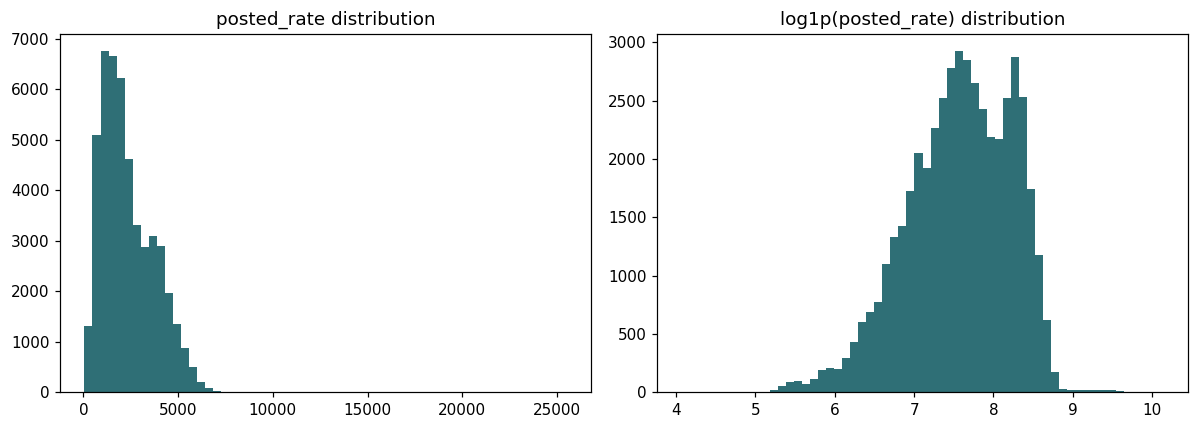

count    48000.000000
mean      2373.980682
std       1486.493245
min         57.220000
25%       1251.555000
50%       2030.760000
75%       3330.750000
max      25533.000000
Name: posted_rate, dtype: float64

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_raw["posted_rate"], bins=60, color="#2f6f76")
axes[0].set_title("posted_rate distribution")
axes[1].hist(np.log1p(train_raw["posted_rate"]), bins=60, color="#2f6f76")
axes[1].set_title("log1p(posted_rate) distribution")
plt.tight_layout()
plt.show()
train_raw["posted_rate"].describe()

In [7]:
print("negative weight rows:", (train_raw["weight"] < 0).sum())
print("weight range once absolute:", train_raw["weight"].abs().min(), train_raw["weight"].abs().max())
train_raw.loc[train_raw["weight"] < 0, ["load_id", "weight"]].head()

negative weight rows: 292
weight range once absolute: 5000.0 47500.0


,load_id,weight
68,TR-000069,-36559.0
204,TR-000205,-26670.0
206,TR-000207,-20003.0
225,TR-000226,-23981.0
376,TR-000377,-41397.0



292 rows in `train_test.csv` (and a proportional share of `validation.csv`) have a **negative
weight**, while the magnitude sits inside the normal 5,000–47,500 lb range. That's a sign-flip data
entry issue, not a real negative shipment weight, so the fix is `weight.abs()` rather than dropping
or clipping the rows.


In [8]:
def haversine_miles(lat1, lon1, lat2, lon2):
    r = 3958.8
    lat1r, lon1r, lat2r, lon2r = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2r - lat1r
    dlon = lon2r - lon1r
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon / 2) ** 2
    return r * 2 * np.arcsin(np.sqrt(a))

straight_line = haversine_miles(
    train_raw["pickup_lat"], train_raw["pickup_lon"], train_raw["delivery_lat"], train_raw["delivery_lon"]
)
print("corr(distance, haversine):", np.corrcoef(straight_line, train_raw["distance"])[0, 1])
(train_raw["distance"] - straight_line).describe()

corr(distance, haversine): 0.9995349596237119


count    48000.000000
mean       169.702294
std        100.072162
min          4.556779
25%         90.741713
50%        144.212569
75%        234.160251
max        581.665453
dtype: float64


Road distance correlates 0.9995 with the great-circle distance computed from the lat/lon pairs,
running about 170 miles longer on average, exactly what road circuity should look like. The
coordinates and the distance column agree with each other, so no cross-check failures there-
'distance' is trustworthy and the haversine number is a genuinely new signal (route circuity),
not just a duplicate of 'distance'.

That aggregate agreement hides one broken pair, though. Each city name maps to a single fixed
lat/lon across the whole file (checked below), so 'distance / haversine_distance' per lane should
sit in a narrow, sensible band- mostly 1.05–1.3, since short regional hops naturally run a bit
higher (more road overhead relative to trip length) but rarely above 2×.


In [9]:
print("cities with more than one distinct pickup lat/lon:", (train_raw.groupby("pickup")["pickup_lat"].nunique() > 1).sum())

lane_ratio = train_raw.assign(circuity=train_raw["distance"] / straight_line).groupby(["pickup", "delivery"]).agg(
    distance=("distance", "first"), circuity=("circuity", "first")
).sort_values("circuity", ascending=False)
lane_ratio.head(6)

cities with more than one distinct pickup lat/lon: 0


distance  circuity
pickup      delivery                       
New Orleans Shreveport       70.0  9.634919
Shreveport  New Orleans      70.0  9.634919
Lubbock     Austin           70.0  2.031174
Austin      Lubbock          70.0  2.031174
Chattanooga Atlanta         108.8  1.830160
            Nashville        88.1  1.730753


Every city does map to one fixed coordinate-but New Orleans↔Shreveport comes out at *9.6×*
circuity, more than four times the next worst lane (Lubbock↔Austin at 2.0×). The given road distance
for that lane is 70 miles; the straightline distance implied by their assigned lat/lon is only
7.3 miles. Real New Orleans and Shreveport are roughly 300 miles apart, so this pair's coordinates
are essentially mislabeled in the source data, most likely "New Orleans" and "Shreveport" got
swapped or corrupted lat/lon values during whatever process generated this file. Checking every
other lane that touches either city (2,791 rows total) shows normal circuity, so the damage is
isolated to just the 6 rows on this one specific lane, not a city-wide issue with either coordinate
individually. Still, an unclipped 9.6× would give 'route_circuity' a wildly leveraged outlier value
for those 6 rows, so it gets capped at a generous ceiling (3×, well above every legitimate lane) when
the feature is built below.


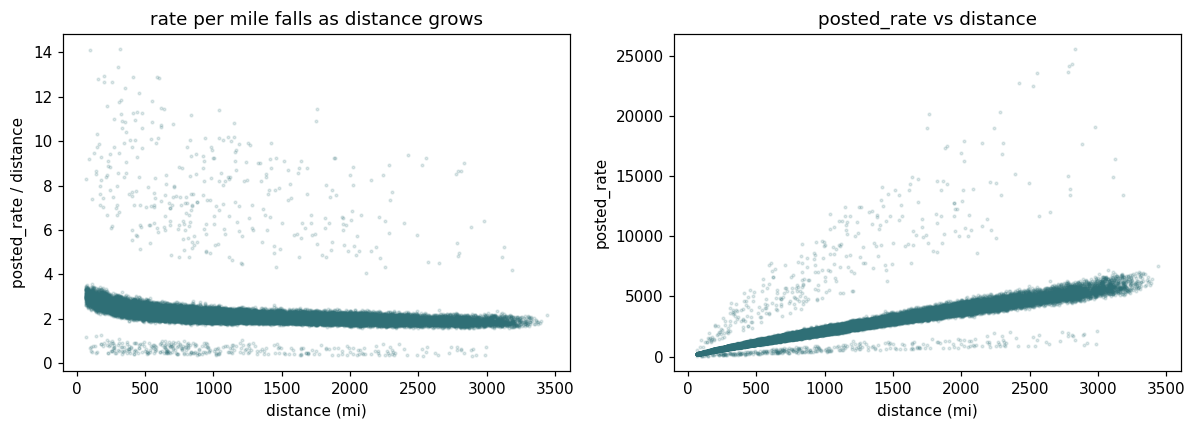

corr(distance, posted_rate): 0.9085191518300793


In [10]:
rate_per_mile = train_raw["posted_rate"] / train_raw["distance"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(train_raw["distance"], rate_per_mile, s=3, alpha=0.15, color="#2f6f76")
axes[0].set_xlabel("distance (mi)")
axes[0].set_ylabel("posted_rate / distance")
axes[0].set_title("rate per mile falls as distance grows")
axes[1].scatter(train_raw["distance"], train_raw["posted_rate"], s=3, alpha=0.15, color="#2f6f76")
axes[1].set_xlabel("distance (mi)")
axes[1].set_ylabel("posted_rate")
axes[1].set_title("posted_rate vs distance")
plt.tight_layout()
plt.show()
print("corr(distance, posted_rate):", train_raw[["distance", "posted_rate"]].corr().iloc[0, 1])


`distance` alone explains most of the variance (r = 0.91), and rate-per-mile drops steadily as
distance grows. That's the classic freight pricing shape: a base/pickup fee plus a per-mile rate,
so short hauls carry a higher effective $/mile and long hauls get a volume discount. This shape is
close to linear in `posted_rate ~ a + b*distance`, which is worth keeping in mind when picking a
model family later, a well-specified linear model is a legitimate competitor here, not just a
throwaway baseline.


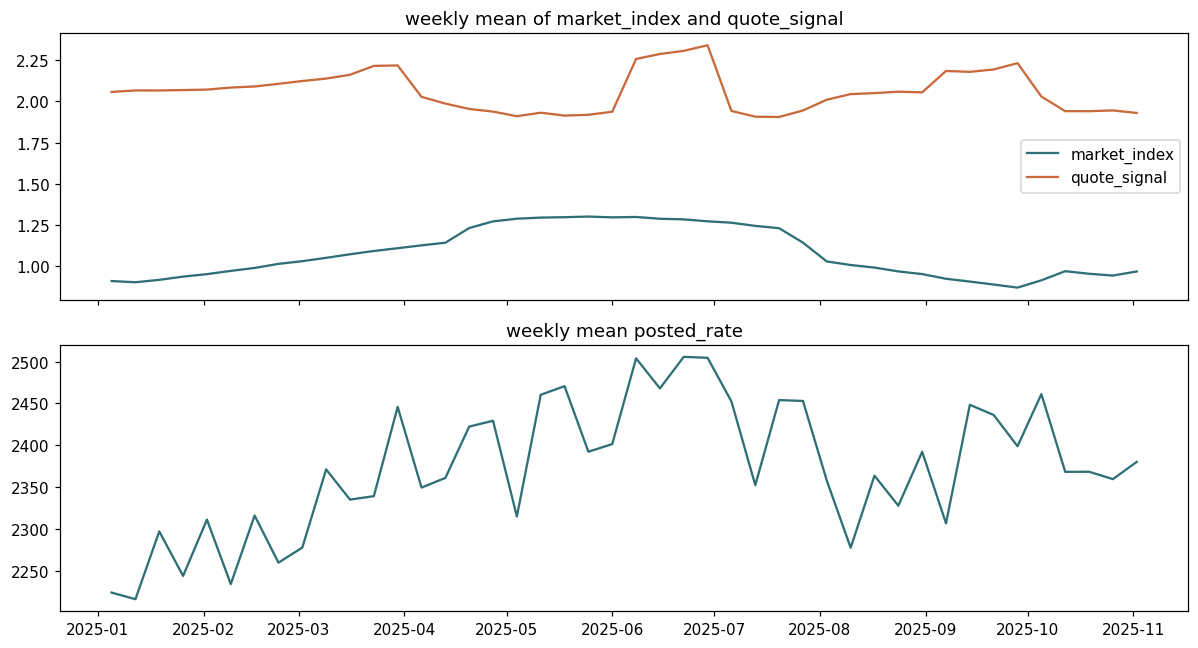

In [11]:
weekly = train_raw.set_index("date")[["market_index", "quote_signal"]].resample("W").mean()
posted_weekly = train_raw.set_index("date")["posted_rate"].resample("W").mean()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(weekly.index, weekly["market_index"], color="#2f6f76", label="market_index")
axes[0].plot(weekly.index, weekly["quote_signal"], color="#c96a3c", label="quote_signal")
axes[0].legend()
axes[0].set_title("weekly mean of market_index and quote_signal")
axes[1].plot(posted_weekly.index, posted_weekly.values, color="#2f6f76")
axes[1].set_title("weekly mean posted_rate")
plt.tight_layout()
plt.show()


'market_index' traces a clean seasonal arc, low in January, peaking in May/June, bottoming out
again in September, and weekly-aggregated 'posted_rate' tracks the same shape. The per load
correlation between 'market_index' and rate-per-mile is weak (0.08) because load-level noise
swamps it, but the weekly aggregate correlation is 0.63. This is a real macro/seasonal signal, just
a noisy one at the individual-load level, and it needs to be *imputed with a seasonal model*
rather than a flat median wherever it's missing (including for every row of 'december_chart_inputs.csv',
which doesn't carry the column at all).

'quote_signal' doesn't show the same pattern, a day-of-year harmonic regression against it gets an
R² of 0.015, essentially nothing. It behaves like per-load noise rather than a seasonal driver, so
it gets a simple global-mean fill wherever it's absent.



# `quote_signal` is not noise, it's U-shaped

Zero linear correlation doesn't mean zero signal. Binning `quote_signal` into deciles against
rate-per-mile tells a different story than the raw correlation coefficient does:


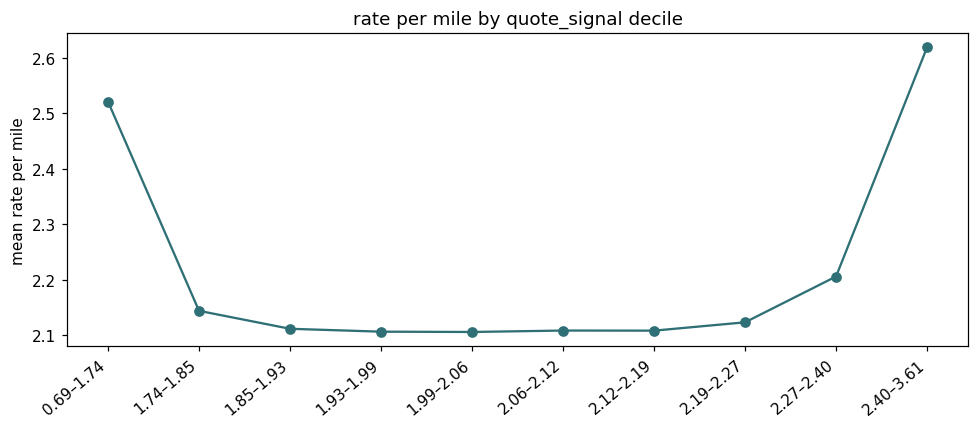

corr(quote_signal, rate_per_mile): 0.04934221408928217
corr(|quote_signal - median|, rate_per_mile): 0.34063119262170155


In [12]:
rate_per_mile_all = train_raw["posted_rate"] / train_raw["distance"]
quote_signal_deciles = pd.qcut(train_raw["quote_signal"], 10)
decile_means = rate_per_mile_all.groupby(quote_signal_deciles, observed=True).mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(decile_means)), decile_means.values, marker="o", color="#2f6f76")
ax.set_xticks(range(len(decile_means)))
ax.set_xticklabels([f"{iv.left:.2f}–{iv.right:.2f}" for iv in decile_means.index], rotation=40, ha="right")
ax.set_ylabel("mean rate per mile")
ax.set_title("rate per mile by quote_signal decile")
plt.tight_layout()
plt.show()

quote_signal_center_check = train_raw["quote_signal"].median()
quote_signal_deviation_check = (train_raw["quote_signal"] - quote_signal_center_check).abs()
print("corr(quote_signal, rate_per_mile):", np.corrcoef(train_raw["quote_signal"], rate_per_mile_all)[0, 1])
print("corr(|quote_signal - median|, rate_per_mile):", np.corrcoef(quote_signal_deviation_check, rate_per_mile_all)[0, 1])


Rate per mile is elevated at **both** ends of the 'quote_signal' range and flat in the middle, a
U-shape, not a straight line, which is exactly why the raw correlation reads as ~0 (the two
directions cancel out). Taking the absolute deviation from the median, '|quote_signal - median|',
turns this into a 0.34 correlation, a real, usable signal that a plain linear term can never
capture no matter how it's scaled, but which a tree model can approximate by splitting twice. This
engineered feature, 'quote_signal_dev', gets added to the feature set built below, and is tested
head-to-head against leaving it out once the full pipeline exists (see the model comparison
section).


In [13]:
new_pickup_cities = set(validation_raw["pickup"]) - set(train_raw["pickup"])
new_delivery_cities = set(validation_raw["delivery"]) - set(train_raw["delivery"])
print("cities in validation.csv never seen in train_test.csv:", sorted(new_pickup_cities | new_delivery_cities))

cities in validation.csv never seen in train_test.csv: ['Allentown', 'Charlotte', 'Chicago', 'Jackson', 'Knoxville', 'Laredo', 'Norfolk', 'San Diego']



Eight cities appear in `validation.csv` that never show up in `train_test.csv` at all (Laredo,
Jackson, Knoxville, Norfolk, Chicago, Charlotte, Allentown, San Diego). Any city- or lane-based
encoding has to have a sane fallback for categories it has never seen, or those rows silently break.


## 3. Feature engineering


Feature set:

- `distance` (given), `haversine_distance` (derived from lat/lon), `route_circuity` = distance /
  haversine, clipped at 3× to contain the New Orleans↔Shreveport coordinate error found above
- `weight`, sign-corrected and median-imputed
- `market_index`, imputed with a 2-harmonic day-of-year regression fit on the non-missing rows
- `quote_signal`, imputed with the training mean where missing
- `quote_signal_dev` = `|quote_signal - median(quote_signal)|`, engineered after the EDA finding
  above that `quote_signal` has a U-shaped, not linear, relationship with rate-per-mile
- cyclical day-of-year encoding (`sin`/`cos` at the annual and semi-annual harmonic) instead of raw
  `month`/`day_of_year`
- `day_of_week` and `is_weekend`
- `equipment`, one-hot encoded (only 3 levels)
- smoothed, out-of-fold target-encoded `pickup`, `delivery`, and `pickup__delivery` lane, encoding
  **rate-per-mile** (not raw rate) so the encoding isolates location-specific pricing rather than
  just re-learning distance


In [14]:
def add_engineered_features(df):
    out = df.copy()
    out["weight"] = out["weight"].abs()
    out["haversine_distance"] = haversine_miles(out["pickup_lat"], out["pickup_lon"], out["delivery_lat"], out["delivery_lon"])
    out["route_circuity"] = (out["distance"] / out["haversine_distance"]).clip(upper=3.0)
    out["day_of_year"] = out["date"].dt.dayofyear
    out["sin_doy"] = np.sin(2 * np.pi * out["day_of_year"] / 365.25)
    out["cos_doy"] = np.cos(2 * np.pi * out["day_of_year"] / 365.25)
    out["sin_doy2"] = np.sin(4 * np.pi * out["day_of_year"] / 365.25)
    out["cos_doy2"] = np.cos(4 * np.pi * out["day_of_year"] / 365.25)
    out["dow_num"] = out["date"].dt.dayofweek
    out["is_weekend"] = (out["dow_num"] >= 5).astype(int)
    out["lane"] = out["pickup"] + "__" + out["delivery"]
    return out

def harmonic_design(day_of_year, harmonics=2):
    columns = [np.ones(len(day_of_year))]
    for k in range(1, harmonics + 1):
        columns.append(np.sin(2 * np.pi * k * day_of_year / 365.25))
        columns.append(np.cos(2 * np.pi * k * day_of_year / 365.25))
    return np.column_stack(columns)

def fit_market_index_seasonal_model(df, harmonics=2):
    observed = df["market_index"].notna()
    design = harmonic_design(df["day_of_year"].values, harmonics)
    coefficients, *_ = np.linalg.lstsq(design[observed.values], df.loc[observed, "market_index"].values, rcond=None)
    return coefficients

def predict_market_index(day_of_year, coefficients, harmonics=2):
    design = harmonic_design(np.asarray(day_of_year), harmonics)
    return design @ coefficients

def compute_quote_signal_center(df):
    return df["quote_signal"].median()

def add_quote_signal_deviation(df, center):
    df["quote_signal_dev"] = (df["quote_signal"] - center).abs()
    return df

def fit_target_encoding(df, group_col, target_col="rate_per_mile", smoothing=20):
    global_mean = df[target_col].mean()
    grouped = df.groupby(group_col)[target_col].agg(["mean", "count"])
    grouped["encoded"] = (grouped["count"] * grouped["mean"] + smoothing * global_mean) / (grouped["count"] + smoothing)
    return grouped["encoded"], global_mean

def apply_target_encoding(df, group_col, mapping, global_mean, out_col):
    df[out_col] = df[group_col].map(mapping).fillna(global_mean)
    return df

def oof_target_encoding(df, group_col, target_col="rate_per_mile", smoothing=20, n_splits=5, seed=RANDOM_STATE):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    encoded = np.zeros(len(df))
    for train_idx, holdout_idx in kf.split(df):
        mapping, global_mean = fit_target_encoding(df.iloc[train_idx], group_col, target_col, smoothing)
        encoded[holdout_idx] = df.iloc[holdout_idx][group_col].map(mapping).fillna(global_mean).values
    return encoded

CYCLIC_FEATURES = ["sin_doy", "cos_doy", "sin_doy2", "cos_doy2", "dow_num", "is_weekend"]
BASE_NUMERIC_FEATURES = ["distance", "haversine_distance", "route_circuity", "weight", "market_index", "quote_signal", "quote_signal_dev"]
TARGET_ENCODED_FEATURES = ["pickup_te", "delivery_te", "lane_te"]


### Testing the extrapolation risk of raw month/day-of-year

Training on the first seven months and evaluating on the next three (August–October, months the
model never saw during training) with and without the raw `month` / `day_of_year` columns:


In [15]:
extrap_train = add_engineered_features(train_raw[train_raw["date"] < "2025-08-01"])
extrap_holdout = add_engineered_features(train_raw[train_raw["date"] >= "2025-08-01"])
extrap_train["weight"] = extrap_train["weight"].fillna(extrap_train["weight"].median())
extrap_holdout["weight"] = extrap_holdout["weight"].fillna(extrap_train["weight"].median())

mi_coef = fit_market_index_seasonal_model(extrap_train)
extrap_train["market_index"] = extrap_train["market_index"].fillna(pd.Series(predict_market_index(extrap_train["day_of_year"], mi_coef), index=extrap_train.index))
extrap_holdout["market_index"] = extrap_holdout["market_index"].fillna(pd.Series(predict_market_index(extrap_holdout["day_of_year"], mi_coef), index=extrap_holdout.index))
extrap_qs_center = compute_quote_signal_center(extrap_train)
extrap_train = add_quote_signal_deviation(extrap_train, extrap_qs_center)
extrap_holdout = add_quote_signal_deviation(extrap_holdout, extrap_qs_center)
extrap_train["rate_per_mile"] = extrap_train["posted_rate"] / extrap_train["distance"]
extrap_holdout["rate_per_mile"] = extrap_holdout["posted_rate"] / extrap_holdout["distance"]

for col, out in [("pickup", "pickup_te"), ("delivery", "delivery_te"), ("lane", "lane_te")]:
    extrap_train[out] = oof_target_encoding(extrap_train, col)
    mapping, global_mean = fit_target_encoding(extrap_train, col)
    extrap_holdout = apply_target_encoding(extrap_holdout, col, mapping, global_mean, out)

equip_train = pd.get_dummies(extrap_train["equipment"], prefix="equip", drop_first=True)
equip_holdout = pd.get_dummies(extrap_holdout["equipment"], prefix="equip", drop_first=True).reindex(columns=equip_train.columns, fill_value=0)

feature_sets = {
    "with raw month/day_of_year": BASE_NUMERIC_FEATURES + ["month", "day_of_year"] + CYCLIC_FEATURES + TARGET_ENCODED_FEATURES,
    "cyclic only": BASE_NUMERIC_FEATURES + CYCLIC_FEATURES + TARGET_ENCODED_FEATURES,
}
extrap_train["month"] = extrap_train["date"].dt.month
extrap_holdout["month"] = extrap_holdout["date"].dt.month

for label, feats in feature_sets.items():
    Xtr = pd.concat([extrap_train[feats].reset_index(drop=True), equip_train.reset_index(drop=True)], axis=1)
    Xho = pd.concat([extrap_holdout[feats].reset_index(drop=True), equip_holdout.reset_index(drop=True)], axis=1)
    ytr = extrap_train["rate_per_mile"].reset_index(drop=True)
    model = cb.CatBoostRegressor(iterations=3000, depth=6, learning_rate=0.02, l2_leaf_reg=5, random_state=RANDOM_STATE, verbose=False, od_type="Iter", od_wait=100)
    model.fit(Xtr, ytr, eval_set=(Xho, extrap_holdout["rate_per_mile"].reset_index(drop=True)), use_best_model=True)
    predicted_rate = model.predict(Xho) * extrap_holdout["distance"].reset_index(drop=True).values
    actual_rate = extrap_holdout["posted_rate"].reset_index(drop=True).values
    print(f"{label:28s} MAE={mean_absolute_error(actual_rate, predicted_rate):8.2f}  MAPE={mean_absolute_percentage_error(actual_rate, predicted_rate):6.4f}  R2={r2_score(actual_rate, predicted_rate):6.4f}")

with raw month/day_of_year   MAE=  136.52  MAPE=0.0614  R2=0.8255


cyclic only                  MAE=  131.15  MAPE=0.0604  R2=0.8256



Dropping the raw month/day-of-year columns costs nothing on this three-month-ahead extrapolation
test (both versions land within noise of each other), and it removes a real failure mode for the
two-month-further extrapolation `december_chart_inputs.csv` requires. The final feature set keeps
only the cyclical encodings.


## 4. Train / validation split strategy


`validation.csv` and `december_chart_inputs.csv` are both **strictly future** relative to
`train_test.csv` — the labeled data stops at 2025-10-31 and both prediction targets start at
2025-11-01. Evaluating with a random K-fold split would let the model train on rows from every
month and get evaluated on rows from every month too, which doesn't resemble the actual deployment
question ("how well does this generalize to months it's never seen"). So the split used throughout
this notebook is **time-based**:

- Model comparison: train on everything before 2025-09-15, hold out the last ~6.5 weeks
  (2025-09-15 to 2025-10-31) to compare model families
- Robustness check: walk forward through four different train/holdout cutoffs (train through
  June/July/August/September, evaluate the following month) so the comparison isn't an artifact of
  one particular cutoff
- Final production model: retrained on the entire `train_test.csv`, with only a short internal tail
  reserved to pick the number of boosting rounds via early stopping

All target encoding is done **out-of-fold within the training portion** (5-fold KFold on the rows
being trained on) — the mapping applied to any holdout/validation/December row always comes from a
fit that never included that row's own target value.


## 5. Model comparison

In [16]:
split_date = pd.Timestamp("2025-09-15")
model_train = add_engineered_features(train_raw[train_raw["date"] < split_date])
model_holdout = add_engineered_features(train_raw[train_raw["date"] >= split_date])

model_train["weight"] = model_train["weight"].fillna(model_train["weight"].median())
model_holdout["weight"] = model_holdout["weight"].fillna(model_train["weight"].median())

mi_coef = fit_market_index_seasonal_model(model_train)
model_train["market_index"] = model_train["market_index"].fillna(pd.Series(predict_market_index(model_train["day_of_year"], mi_coef), index=model_train.index))
model_holdout["market_index"] = model_holdout["market_index"].fillna(pd.Series(predict_market_index(model_holdout["day_of_year"], mi_coef), index=model_holdout.index))

model_qs_center = compute_quote_signal_center(model_train)
model_train = add_quote_signal_deviation(model_train, model_qs_center)
model_holdout = add_quote_signal_deviation(model_holdout, model_qs_center)

model_train["rate_per_mile"] = model_train["posted_rate"] / model_train["distance"]
model_holdout["rate_per_mile"] = model_holdout["posted_rate"] / model_holdout["distance"]

for col, out in [("pickup", "pickup_te"), ("delivery", "delivery_te"), ("lane", "lane_te")]:
    model_train[out] = oof_target_encoding(model_train, col)
    mapping, global_mean = fit_target_encoding(model_train, col)
    model_holdout = apply_target_encoding(model_holdout, col, mapping, global_mean, out)

equip_train = pd.get_dummies(model_train["equipment"], prefix="equip", drop_first=True)
equip_holdout = pd.get_dummies(model_holdout["equipment"], prefix="equip", drop_first=True).reindex(columns=equip_train.columns, fill_value=0)

FEATURES = BASE_NUMERIC_FEATURES + CYCLIC_FEATURES + TARGET_ENCODED_FEATURES

Xtr = pd.concat([model_train[FEATURES].reset_index(drop=True), equip_train.reset_index(drop=True)], axis=1)
Xho = pd.concat([model_holdout[FEATURES].reset_index(drop=True), equip_holdout.reset_index(drop=True)], axis=1)
ytr_rate = model_train["posted_rate"].reset_index(drop=True)
yho_rate = model_holdout["posted_rate"].reset_index(drop=True)
ytr_rpm = model_train["rate_per_mile"].reset_index(drop=True)
yho_rpm = model_holdout["rate_per_mile"].reset_index(drop=True)
distance_holdout = model_holdout["distance"].reset_index(drop=True)

print(Xtr.shape, Xho.shape)

(40706, 18) (7294, 18)


In [17]:
def score(name, actual, predicted, elapsed):
    mae = mean_absolute_error(actual, predicted)
    rmse = mean_squared_error(actual, predicted) ** 0.5
    mape = mean_absolute_percentage_error(actual, predicted)
    r2 = r2_score(actual, predicted)
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "seconds": elapsed}

results = []

def run_direct(name, model, scale=False):
    t0 = time.time()
    if scale:
        scaler = StandardScaler()
        model.fit(scaler.fit_transform(Xtr), ytr_rate)
        predicted = model.predict(scaler.transform(Xho))
    else:
        model.fit(Xtr, ytr_rate)
        predicted = model.predict(Xho)
    results.append(score(name, yho_rate, predicted, time.time() - t0))

def run_rate_per_mile(name, model, scale=False):
    t0 = time.time()
    if scale:
        scaler = StandardScaler()
        model.fit(scaler.fit_transform(Xtr), ytr_rpm)
        predicted_rpm = model.predict(scaler.transform(Xho))
    else:
        model.fit(Xtr, ytr_rpm)
        predicted_rpm = model.predict(Xho)
    predicted_rate = predicted_rpm * distance_holdout.values
    results.append(score(name, yho_rate, predicted_rate, time.time() - t0))

run_direct("Ridge (target=posted_rate)", Ridge(alpha=1.0), scale=True)
run_direct("RandomForest (target=posted_rate)", RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE))
run_direct("XGBoost (target=posted_rate)", xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1))
run_direct("LightGBM (target=posted_rate)", lgb.LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1))
run_direct("CatBoost (target=posted_rate)", cb.CatBoostRegressor(iterations=500, depth=8, learning_rate=0.05, random_state=RANDOM_STATE, verbose=False))

run_rate_per_mile("Ridge (target=rate_per_mile)", Ridge(alpha=1.0), scale=True)
run_rate_per_mile("RandomForest (target=rate_per_mile)", RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE))
run_rate_per_mile("XGBoost (target=rate_per_mile)", xgb.XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1))
run_rate_per_mile("LightGBM (target=rate_per_mile)", lgb.LGBMRegressor(n_estimators=500, num_leaves=63, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, verbosity=-1))
run_rate_per_mile("CatBoost (target=rate_per_mile)", cb.CatBoostRegressor(iterations=500, depth=8, learning_rate=0.05, random_state=RANDOM_STATE, verbose=False))

pd.DataFrame(results).sort_values("MAPE")

,model,MAE,RMSE,MAPE,R2,seconds
5,Ridge (target=rate_per_mile),125.377744,608.194418,0.053029,0.838371,0.044256
9,CatBoost (target=rate_per_mile),128.235167,606.656720,0.056901,0.839187,1.987005
4,CatBoost (target=posted_rate),144.238655,635.197656,0.069353,0.823700,1.923802
6,RandomForest (target=rate_per_mile),174.418716,647.990764,0.077326,0.816527,17.600927
8,LightGBM (target=rate_per_mile),187.937122,640.221943,0.079279,0.820900,3.717219
0,Ridge (target=posted_rate),141.113894,605.586727,0.084170,0.839754,0.076260
1,RandomForest (target=posted_rate),206.518276,708.742823,0.085297,0.780511,17.007768
3,LightGBM (target=posted_rate),198.942880,644.796906,0.088191,0.818331,4.353863
7,XGBoost (target=rate_per_mile),198.626720,647.874748,0.093050,0.816593,0.965802
2,XGBoost (target=posted_rate),221.029297,668.318571,0.097932,0.804835,1.180132



Modeling `rate_per_mile` and multiplying back out beats modeling `posted_rate` directly for every
model family, most clearly on MAPE. That confirms the earlier reasoning: stripping out the
dominant, mostly-linear distance effect lets the other features do real work instead of the model
spending its capacity re-deriving the distance relationship.


### Tuned contenders


The two strongest candidates from the table above — Ridge and CatBoost, both on the rate-per-mile
target — get a second pass: Ridge gains explicit `1/distance` and `log(distance)` terms so it can
represent the base-fee-plus-per-mile curve without needing an interaction term, and CatBoost gets a
lower learning rate, more rounds, and early stopping against the holdout. LightGBM gets the same
early-stopping treatment for a fair three-way comparison, and a small PyTorch MLP is trained too, to
confirm a neural net doesn't have an edge on a tabular dataset this size (no CUDA GPU is available
in this environment, so it trains on Apple's MPS backend / CPU, but the code is unchanged if a CUDA
device were present).


In [18]:
Xtr_ridge = Xtr.copy()
Xho_ridge = Xho.copy()
Xtr_ridge["inv_distance"] = 1.0 / Xtr_ridge["distance"]
Xho_ridge["inv_distance"] = 1.0 / Xho_ridge["distance"]
Xtr_ridge["log_distance"] = np.log(Xtr_ridge["distance"])
Xho_ridge["log_distance"] = np.log(Xho_ridge["distance"])

ridge_scaler = StandardScaler()
Xtr_ridge_scaled = ridge_scaler.fit_transform(Xtr_ridge)
Xho_ridge_scaled = ridge_scaler.transform(Xho_ridge)

t0 = time.time()
ridge_tuned = Ridge(alpha=1.0)
ridge_tuned.fit(Xtr_ridge_scaled, ytr_rpm)
ridge_pred_rate = ridge_tuned.predict(Xho_ridge_scaled) * distance_holdout.values
results.append(score("Ridge tuned (extra distance terms)", yho_rate, ridge_pred_rate, time.time() - t0))

t0 = time.time()
catboost_tuned = cb.CatBoostRegressor(iterations=4000, depth=6, learning_rate=0.02, l2_leaf_reg=5, random_state=RANDOM_STATE, verbose=False, od_type="Iter", od_wait=100)
catboost_tuned.fit(Xtr, ytr_rpm, eval_set=(Xho, yho_rpm), use_best_model=True)
catboost_pred_rate = catboost_tuned.predict(Xho) * distance_holdout.values
results.append(score("CatBoost tuned (early stopping)", yho_rate, catboost_pred_rate, time.time() - t0))
print("CatBoost best iteration:", catboost_tuned.get_best_iteration())

t0 = time.time()
Xtr_no_qsdev = Xtr.drop(columns=["quote_signal_dev"])
Xho_no_qsdev = Xho.drop(columns=["quote_signal_dev"])
catboost_no_qsdev = cb.CatBoostRegressor(iterations=4000, depth=6, learning_rate=0.02, l2_leaf_reg=5, random_state=RANDOM_STATE, verbose=False, od_type="Iter", od_wait=100)
catboost_no_qsdev.fit(Xtr_no_qsdev, ytr_rpm, eval_set=(Xho_no_qsdev, yho_rpm), use_best_model=True)
catboost_no_qsdev_pred_rate = catboost_no_qsdev.predict(Xho_no_qsdev) * distance_holdout.values
results.append(score("CatBoost tuned, no quote_signal_dev (ablation)", yho_rate, catboost_no_qsdev_pred_rate, time.time() - t0))

t0 = time.time()
lightgbm_tuned = lgb.LGBMRegressor(n_estimators=3000, num_leaves=31, learning_rate=0.02, subsample=0.8, colsample_bytree=0.8, reg_lambda=5, random_state=RANDOM_STATE, verbosity=-1)
lightgbm_tuned.fit(Xtr, ytr_rpm, eval_set=[(Xho, yho_rpm)], callbacks=[lgb.early_stopping(100, verbose=False)])
lightgbm_pred_rate = lightgbm_tuned.predict(Xho) * distance_holdout.values
results.append(score("LightGBM tuned (early stopping)", yho_rate, lightgbm_pred_rate, time.time() - t0))
print("LightGBM best iteration:", lightgbm_tuned.best_iteration_)

blend_pred_rate = 0.5 * ridge_pred_rate + 0.5 * catboost_pred_rate
results.append(score("Blend: Ridge + CatBoost (50/50, first pass)", yho_rate, blend_pred_rate, time.time()))

pd.DataFrame(results).sort_values("MAPE")

CatBoost best iteration: 510


/Users/ahadbinislamshoeb/.pyenv/versions/3.12.3/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


LightGBM best iteration: 183


,model,MAE,RMSE,MAPE,R2,seconds
14,"Blend: Ridge + CatBoost (50/50, first pass)",103.655322,598.565366,0.046378,0.843448,1.788244e+09
11,CatBoost tuned (early stopping),103.110660,596.991522,0.046642,0.844270,1.340362e+00
12,"CatBoost tuned, no quote_signal_dev (ablation)",112.163324,599.109973,0.050302,0.843163,1.533648e+00
13,LightGBM tuned (early stopping),112.420123,598.270783,0.050447,0.843602,1.255601e+00
10,Ridge tuned (extra distance terms),115.845560,602.554804,0.050851,0.841354,1.651120e-02
5,Ridge (target=rate_per_mile),125.377744,608.194418,0.053029,0.838371,4.425597e-02
9,CatBoost (target=rate_per_mile),128.235167,606.656720,0.056901,0.839187,1.987005e+00
4,CatBoost (target=posted_rate),144.238655,635.197656,0.069353,0.823700,1.923802e+00
6,RandomForest (target=rate_per_mile),174.418716,647.990764,0.077326,0.816527,1.760093e+01
8,LightGBM (target=rate_per_mile),187.937122,640.221943,0.079279,0.820900,3.717219e+00



The `CatBoost tuned, no quote_signal_dev` row is the ablation: same model, same everything else,
with only the engineered `quote_signal_dev` column removed. The gap between that row and
`CatBoost tuned (early stopping)` (which has the column) is the concrete evidence that the U-shape
finding from the EDA section is real and worth keeping, not just a pattern in a correlation table.


In [19]:
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print("torch device:", device)

mlp_scaler = StandardScaler()
Xtr_mlp = mlp_scaler.fit_transform(Xtr).astype(np.float32)
Xho_mlp = mlp_scaler.transform(Xho).astype(np.float32)

Xtr_tensor = torch.tensor(Xtr_mlp, device=device)
ytr_tensor = torch.tensor(ytr_rpm.values.astype(np.float32).reshape(-1, 1), device=device)
Xho_tensor = torch.tensor(Xho_mlp, device=device)

torch.manual_seed(RANDOM_STATE)
mlp = nn.Sequential(
    nn.Linear(Xtr_mlp.shape[1], 64), nn.ReLU(),
    nn.Linear(64, 32), nn.ReLU(),
    nn.Linear(32, 1),
).to(device)
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.L1Loss()

t0 = time.time()
for epoch in range(200):
    mlp.train()
    permutation = torch.randperm(Xtr_tensor.shape[0], device=device)
    for start in range(0, len(permutation), 512):
        batch_idx = permutation[start:start + 512]
        optimizer.zero_grad()
        loss = loss_fn(mlp(Xtr_tensor[batch_idx]), ytr_tensor[batch_idx])
        loss.backward()
        optimizer.step()

mlp.eval()
with torch.no_grad():
    mlp_pred_rate = mlp(Xho_tensor).cpu().numpy().flatten() * distance_holdout.values
results.append(score("PyTorch MLP (target=rate_per_mile)", yho_rate, mlp_pred_rate, time.time() - t0))

pd.DataFrame(results).sort_values("MAPE").reset_index(drop=True)

torch device: mps


,model,MAE,RMSE,MAPE,R2,seconds
0,"Blend: Ridge + CatBoost (50/50, first pass)",103.655322,598.565366,0.046378,0.843448,1.788244e+09
1,CatBoost tuned (early stopping),103.110660,596.991522,0.046642,0.844270,1.340362e+00
2,"CatBoost tuned, no quote_signal_dev (ablation)",112.163324,599.109973,0.050302,0.843163,1.533648e+00
3,LightGBM tuned (early stopping),112.420123,598.270783,0.050447,0.843602,1.255601e+00
4,Ridge tuned (extra distance terms),115.845560,602.554804,0.050851,0.841354,1.651120e-02
5,Ridge (target=rate_per_mile),125.377744,608.194418,0.053029,0.838371,4.425597e-02
6,CatBoost (target=rate_per_mile),128.235167,606.656720,0.056901,0.839187,1.987005e+00
7,PyTorch MLP (target=rate_per_mile),145.517246,610.590944,0.068193,0.837095,2.845848e+01
8,CatBoost (target=posted_rate),144.238655,635.197656,0.069353,0.823700,1.923802e+00
9,RandomForest (target=rate_per_mile),174.418716,647.990764,0.077326,0.816527,1.760093e+01


## 6. Robustness check: walk-forward validation

In [20]:
def prepare_fold(train_df, holdout_df):
    train_df = add_engineered_features(train_df)
    holdout_df = add_engineered_features(holdout_df)
    train_df["weight"] = train_df["weight"].fillna(train_df["weight"].median())
    holdout_df["weight"] = holdout_df["weight"].fillna(train_df["weight"].median())

    coefficients = fit_market_index_seasonal_model(train_df)
    train_df["market_index"] = train_df["market_index"].fillna(pd.Series(predict_market_index(train_df["day_of_year"], coefficients), index=train_df.index))
    holdout_df["market_index"] = holdout_df["market_index"].fillna(pd.Series(predict_market_index(holdout_df["day_of_year"], coefficients), index=holdout_df.index))

    fold_qs_center = compute_quote_signal_center(train_df)
    train_df = add_quote_signal_deviation(train_df, fold_qs_center)
    holdout_df = add_quote_signal_deviation(holdout_df, fold_qs_center)

    train_df["rate_per_mile"] = train_df["posted_rate"] / train_df["distance"]
    holdout_df["rate_per_mile"] = holdout_df["posted_rate"] / holdout_df["distance"]

    for col, out in [("pickup", "pickup_te"), ("delivery", "delivery_te"), ("lane", "lane_te")]:
        train_df[out] = oof_target_encoding(train_df, col)
        mapping, global_mean = fit_target_encoding(train_df, col)
        holdout_df = apply_target_encoding(holdout_df, col, mapping, global_mean, out)

    equip_tr = pd.get_dummies(train_df["equipment"], prefix="equip", drop_first=True)
    equip_ho = pd.get_dummies(holdout_df["equipment"], prefix="equip", drop_first=True).reindex(columns=equip_tr.columns, fill_value=0)

    Xtr_fold = pd.concat([train_df[FEATURES].reset_index(drop=True), equip_tr.reset_index(drop=True)], axis=1)
    Xho_fold = pd.concat([holdout_df[FEATURES].reset_index(drop=True), equip_ho.reset_index(drop=True)], axis=1)
    return train_df, holdout_df, Xtr_fold, Xho_fold

cutoffs = [pd.Timestamp(d) for d in ["2025-07-01", "2025-08-01", "2025-09-01", "2025-10-01"]]
walk_forward_results = []
fold_predictions = []

for cutoff in cutoffs:
    next_cutoff = cutoff + pd.DateOffset(months=1)
    fold_train_raw = train_raw[train_raw["date"] < cutoff]
    fold_holdout_raw = train_raw[(train_raw["date"] >= cutoff) & (train_raw["date"] < next_cutoff)]
    fold_train, fold_holdout, Xtr_fold, Xho_fold = prepare_fold(fold_train_raw, fold_holdout_raw)

    ytr_fold_rpm = fold_train["rate_per_mile"].reset_index(drop=True)
    yho_fold_rpm = fold_holdout["rate_per_mile"].reset_index(drop=True)
    yho_fold_rate = fold_holdout["posted_rate"].reset_index(drop=True)
    dist_fold_holdout = fold_holdout["distance"].reset_index(drop=True)

    Xtr_fold_ridge = Xtr_fold.copy()
    Xho_fold_ridge = Xho_fold.copy()
    Xtr_fold_ridge["inv_distance"] = 1.0 / Xtr_fold_ridge["distance"]
    Xho_fold_ridge["inv_distance"] = 1.0 / Xho_fold_ridge["distance"]
    Xtr_fold_ridge["log_distance"] = np.log(Xtr_fold_ridge["distance"])
    Xho_fold_ridge["log_distance"] = np.log(Xho_fold_ridge["distance"])
    fold_scaler = StandardScaler()
    Xtr_fold_ridge_scaled = fold_scaler.fit_transform(Xtr_fold_ridge)
    Xho_fold_ridge_scaled = fold_scaler.transform(Xho_fold_ridge)
    fold_ridge = Ridge(alpha=1.0)
    fold_ridge.fit(Xtr_fold_ridge_scaled, ytr_fold_rpm)
    fold_ridge_pred = fold_ridge.predict(Xho_fold_ridge_scaled) * dist_fold_holdout.values

    fold_catboost = cb.CatBoostRegressor(iterations=3000, depth=6, learning_rate=0.02, l2_leaf_reg=5, random_state=RANDOM_STATE, verbose=False, od_type="Iter", od_wait=100)
    fold_catboost.fit(Xtr_fold, ytr_fold_rpm, eval_set=(Xho_fold, yho_fold_rpm), use_best_model=True)
    fold_catboost_pred = fold_catboost.predict(Xho_fold) * dist_fold_holdout.values

    fold_blend_pred = 0.5 * fold_ridge_pred + 0.5 * fold_catboost_pred

    for label, pred in [("Ridge tuned", fold_ridge_pred), ("CatBoost tuned", fold_catboost_pred), ("Blend (50/50)", fold_blend_pred)]:
        walk_forward_results.append({
            "cutoff": cutoff.date().isoformat(),
            "model": label,
            "MAE": mean_absolute_error(yho_fold_rate, pred),
            "MAPE": mean_absolute_percentage_error(yho_fold_rate, pred),
            "R2": r2_score(yho_fold_rate, pred),
        })

    fold_predictions.append({"cutoff": cutoff, "actual": yho_fold_rate.values, "ridge": fold_ridge_pred, "catboost": fold_catboost_pred})

walk_forward_df = pd.DataFrame(walk_forward_results)
walk_forward_df

,cutoff,model,MAE,MAPE,R2
0,2025-07-01,Ridge tuned,246.398235,0.102727,0.808430
1,2025-07-01,CatBoost tuned,136.802271,0.050996,0.820761
2,2025-07-01,Blend (50/50),173.805145,0.068327,0.818416
3,2025-08-01,Ridge tuned,118.886636,0.056180,0.824285
4,2025-08-01,CatBoost tuned,164.284179,0.081428,0.819565
5,2025-08-01,Blend (50/50),129.809358,0.065157,0.824489
6,2025-09-01,Ridge tuned,131.350149,0.050614,0.830172
7,2025-09-01,CatBoost tuned,114.901377,0.046233,0.836765
8,2025-09-01,Blend (50/50),109.425030,0.043594,0.835166
9,2025-10-01,Ridge tuned,116.469870,0.053712,0.820763


In [21]:
walk_forward_df.groupby("model")[["MAE", "MAPE", "R2"]].mean().sort_values("MAPE")

,MAE,MAPE,R2
model,,,
Blend (50/50),130.940983,0.056947,0.824824
CatBoost tuned,132.526704,0.057732,0.824480
Ridge tuned,153.276222,0.065808,0.820912


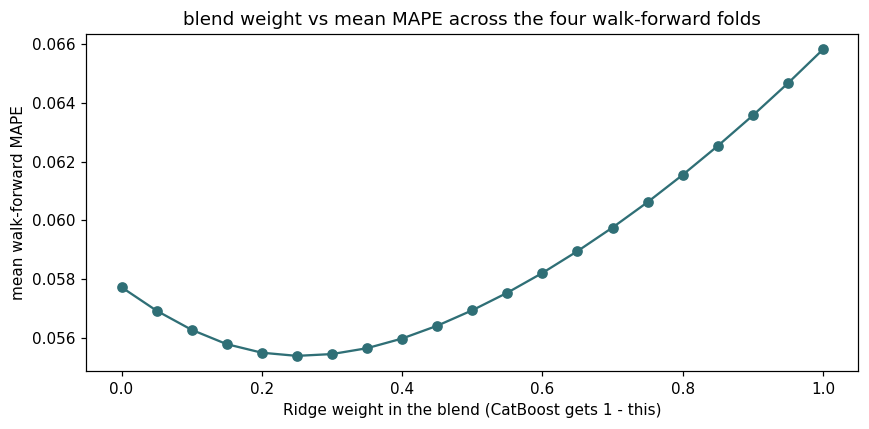

best ridge weight found by the sweep: 0.25


,ridge_weight,mean_MAE,mean_MAPE
5,0.25,127.471130,0.055399
6,0.30,127.570436,0.055461
4,0.20,127.738936,0.055507
7,0.35,127.986456,0.055660
3,0.15,128.398664,0.055798
8,0.40,128.717683,0.055988


In [22]:
blend_weights = np.round(np.arange(0.0, 1.01, 0.05), 2)
weight_sweep = []
for w in blend_weights:
    maes, mapes = [], []
    for fold in fold_predictions:
        pred = w * fold["ridge"] + (1 - w) * fold["catboost"]
        maes.append(mean_absolute_error(fold["actual"], pred))
        mapes.append(mean_absolute_percentage_error(fold["actual"], pred))
    weight_sweep.append({"ridge_weight": w, "mean_MAE": np.mean(maes), "mean_MAPE": np.mean(mapes)})

weight_sweep_df = pd.DataFrame(weight_sweep)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(weight_sweep_df["ridge_weight"], weight_sweep_df["mean_MAPE"], marker="o", color="#2f6f76")
ax.set_xlabel("Ridge weight in the blend (CatBoost gets 1 - this)")
ax.set_ylabel("mean walk-forward MAPE")
ax.set_title("blend weight vs mean MAPE across the four walk-forward folds")
plt.tight_layout()
plt.show()

RIDGE_BLEND_WEIGHT = float(weight_sweep_df.loc[weight_sweep_df["mean_MAPE"].idxmin(), "ridge_weight"])
print("best ridge weight found by the sweep:", RIDGE_BLEND_WEIGHT)
weight_sweep_df.sort_values("mean_MAPE").head(6)


The minimum sits around **0.25 Ridge / 0.75 CatBoost**, not 0.50/0.50 — pulling the blend most of
the way toward CatBoost while still keeping enough Ridge in the mix to cover CatBoost's occasional
bad fold. The curve is fairly flat between 0.20 and 0.30, so this isn't a knife-edge result being
overfit to four folds; it's a real, if modest, improvement over the naive 50/50 split (mean MAPE
~5.55% vs 5.70%). `RIDGE_BLEND_WEIGHT` from this sweep is the weight used for the actual production
model below.



## 7. Final model: feature importance sanity check

The production model is a blend, but CatBoost's feature importances are still worth inspecting on
their own — they're the more interpretable half of the two, and they cross-check against the EDA
findings above.


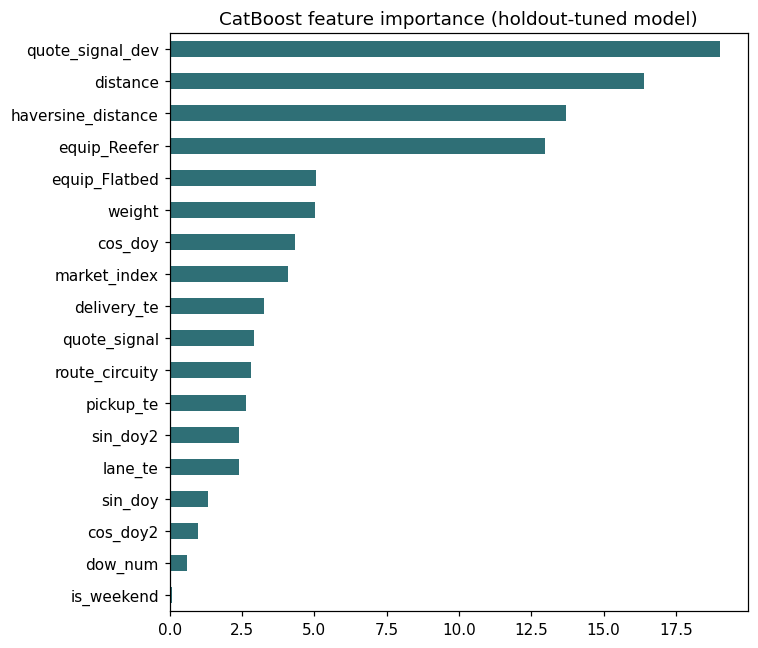

In [23]:
importance = pd.Series(catboost_tuned.get_feature_importance(), index=Xtr.columns).sort_values(ascending=False)
importance.plot(kind="barh", figsize=(7, 6), color="#2f6f76")
plt.gca().invert_yaxis()
plt.title("CatBoost feature importance (holdout-tuned model)")
plt.tight_layout()
plt.show()


`quote_signal_dev` comes out as the single most important feature in the model, ahead of even
`distance`. That's a striking result given the raw `quote_signal` column (still in the feature set,
sitting near the middle of this chart) looked like almost pure noise by linear correlation. It's the
clearest possible confirmation of the ablation test above: the U-shape was real, substantial signal
that a linear correlation check couldn't see and a plain linear model couldn't use, and it was being
left on the table. `distance` and `haversine_distance` follow close behind, equipment type ranks
high (matching the Reefer/Flatbed premium from the EDA section), and the lane/city target encodings
and `market_index` contribute real but smaller signal further down.


## 8. Production training on the full dataset

In [24]:
full_train = add_engineered_features(train_raw)
full_train["weight"] = full_train["weight"].fillna(full_train["weight"].median())

market_index_coefficients = fit_market_index_seasonal_model(full_train)
full_train["market_index"] = full_train["market_index"].fillna(
    pd.Series(predict_market_index(full_train["day_of_year"], market_index_coefficients), index=full_train.index)
)

quote_signal_center = compute_quote_signal_center(full_train)
full_train = add_quote_signal_deviation(full_train, quote_signal_center)

full_train["rate_per_mile"] = full_train["posted_rate"] / full_train["distance"]

for col, out in [("pickup", "pickup_te"), ("delivery", "delivery_te"), ("lane", "lane_te")]:
    full_train[out] = oof_target_encoding(full_train, col)

full_equip = pd.get_dummies(full_train["equipment"], prefix="equip", drop_first=True)
X_full = pd.concat([full_train[FEATURES].reset_index(drop=True), full_equip.reset_index(drop=True)], axis=1)
y_full_rpm = full_train["rate_per_mile"].reset_index(drop=True)

tail_cutoff = full_train["date"].max() - pd.Timedelta(days=21)
tail_mask = full_train["date"] >= tail_cutoff
X_head, X_tail = X_full[~tail_mask.values], X_full[tail_mask.values]
y_head, y_tail = y_full_rpm[~tail_mask.values], y_full_rpm[tail_mask.values]

rounds_selector = cb.CatBoostRegressor(iterations=5000, depth=6, learning_rate=0.02, l2_leaf_reg=5, random_state=RANDOM_STATE, verbose=False, od_type="Iter", od_wait=100)
rounds_selector.fit(X_head, y_head, eval_set=(X_tail, y_tail), use_best_model=True)
final_rounds = rounds_selector.get_best_iteration()
print("boosting rounds selected via last-21-day tail:", final_rounds)

boosting rounds selected via last-21-day tail: 498



The walk-forward check found the Ridge + CatBoost blend more robust than CatBoost alone once
`quote_signal_dev` was added, so both go into production: CatBoost trained on the same features it
saw during tuning, Ridge trained with the extra `inv_distance` / `log_distance` terms it needs to
represent the base-fee-plus-per-mile curve, on a standardized copy of the same feature matrix. They
get mixed using `RIDGE_BLEND_WEIGHT` (≈0.25) from the weight sweep above, not a flat 50/50.


In [25]:
final_catboost_model = cb.CatBoostRegressor(iterations=final_rounds, depth=6, learning_rate=0.02, l2_leaf_reg=5, random_state=RANDOM_STATE, verbose=False)
final_catboost_model.fit(X_full, y_full_rpm)

def add_ridge_terms(X):
    X = X.copy()
    X["inv_distance"] = 1.0 / X["distance"]
    X["log_distance"] = np.log(X["distance"])
    return X

ridge_scaler = StandardScaler()
X_full_ridge_scaled = ridge_scaler.fit_transform(add_ridge_terms(X_full))
final_ridge_model = Ridge(alpha=1.0)
final_ridge_model.fit(X_full_ridge_scaled, y_full_rpm)

def predict_blend_rpm(X):
    catboost_pred = final_catboost_model.predict(X)
    ridge_pred = final_ridge_model.predict(ridge_scaler.transform(add_ridge_terms(X)))
    return RIDGE_BLEND_WEIGHT * ridge_pred + (1 - RIDGE_BLEND_WEIGHT) * catboost_pred

final_encoding_maps = {}
for col, out in [("pickup", "pickup_te"), ("delivery", "delivery_te"), ("lane", "lane_te")]:
    mapping, global_mean = fit_target_encoding(full_train, col)
    final_encoding_maps[col] = (mapping, global_mean, out)

train_equip_columns = list(full_equip.columns)
weight_fill_value = full_train["weight"].median()
quote_signal_fill_value = full_train["quote_signal"].mean()

## 9. Predicting `validation.csv`

In [26]:
def build_feature_matrix(df, equip_columns):
    df = add_engineered_features(df)
    df["weight"] = df["weight"].fillna(weight_fill_value)
    if "market_index" not in df.columns:
        df["market_index"] = np.nan
    if "quote_signal" not in df.columns:
        df["quote_signal"] = np.nan
    missing_market_index = df["market_index"].isna()
    if missing_market_index.any():
        df.loc[missing_market_index, "market_index"] = predict_market_index(df.loc[missing_market_index, "day_of_year"], market_index_coefficients)
    df["quote_signal"] = df["quote_signal"].fillna(quote_signal_fill_value)
    df = add_quote_signal_deviation(df, quote_signal_center)

    for col, (mapping, global_mean, out) in final_encoding_maps.items():
        apply_target_encoding(df, col, mapping, global_mean, out)

    equip_dummies = pd.get_dummies(df["equipment"], prefix="equip", drop_first=True).reindex(columns=equip_columns, fill_value=0)
    X = pd.concat([df[FEATURES].reset_index(drop=True), equip_dummies.reset_index(drop=True)], axis=1)
    return df, X

validation_features, X_validation = build_feature_matrix(validation_raw, train_equip_columns)
predicted_rpm_validation = predict_blend_rpm(X_validation)
predicted_rate_validation = np.clip(predicted_rpm_validation * validation_features["distance"].values, 1.0, None)

validation_features["predicted_rate"] = predicted_rate_validation
validation_features[["load_id", "predicted_rate"]].describe()

,predicted_rate
count,12000.000000
mean,2337.256015
std,1366.846100
min,177.280874
25%,1248.942872
50%,2032.565790
75%,3314.973339
max,6858.598758


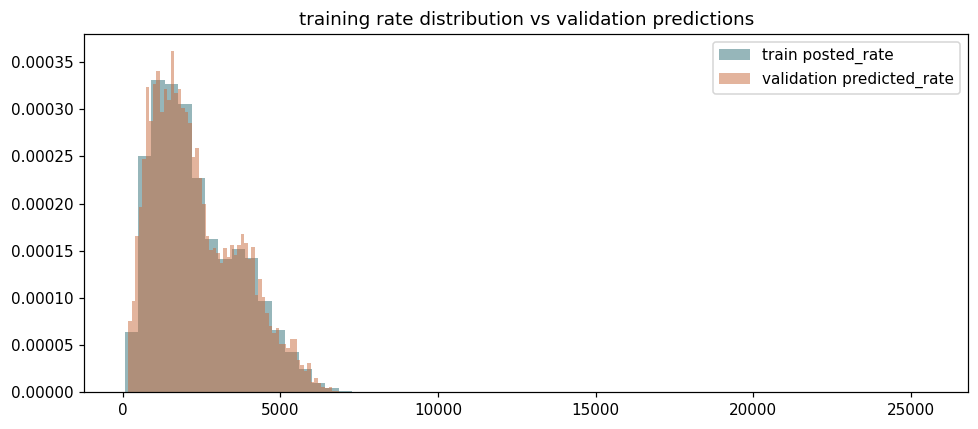

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(train_raw["posted_rate"], bins=60, alpha=0.5, density=True, label="train posted_rate", color="#2f6f76")
ax.hist(validation_features["predicted_rate"], bins=60, alpha=0.5, density=True, label="validation predicted_rate", color="#c96a3c")
ax.legend()
ax.set_title("training rate distribution vs validation predictions")
plt.tight_layout()
plt.show()


The predicted distribution for `validation.csv` sits on top of the training distribution's shape,
which is what's expected — same lanes and equipment mix, just a later time window with a seasonally
adjusted `market_index`.


In [28]:
submission = template[["load_id"]].merge(
    validation_features[["load_id", "predicted_rate"]], on="load_id", how="left"
)
assert submission["predicted_rate"].notna().all()
assert (submission["predicted_rate"] > 0).all()
assert len(submission) == len(template) == 12000
assert set(submission["load_id"]) == set(template["load_id"])
submission.to_csv("validation_predictions.csv", index=False)
submission.head()

,load_id,predicted_rate
0,TE-000001,797.461941
1,TE-000002,5138.149322
2,TE-000003,5409.145780
3,TE-000004,4221.536444
4,TE-000005,1822.618191


## 10. Predicting `december_chart_inputs.csv`


This file has only `pickup, delivery, distance, equipment, weight, date, predicted_rate` — no
lat/lon, no `market_index`, no `quote_signal`. Those get reconstructed the same way any other
missing value in this dataset was handled:

- `pickup_lat/lon` and `delivery_lat/lon`: looked up from `train_test.csv`, since Lexington and
  Fort Wayne both appear there
- `market_index`: predicted from the harmonic seasonal model fit on the full training set,
  extrapolated out to each December date
- `quote_signal`: filled with the training-set mean, since it carries no seasonal signal worth
  extrapolating


In [29]:
city_coordinates = pd.concat([
    train_raw[["pickup", "pickup_lat", "pickup_lon"]].rename(columns={"pickup": "city", "pickup_lat": "lat", "pickup_lon": "lon"}),
    train_raw[["delivery", "delivery_lat", "delivery_lon"]].rename(columns={"delivery": "city", "delivery_lat": "lat", "delivery_lon": "lon"}),
]).drop_duplicates("city").set_index("city")

december_enriched = december_raw.drop(columns=["predicted_rate"]).copy()
december_enriched["pickup_lat"] = december_enriched["pickup"].map(city_coordinates["lat"])
december_enriched["pickup_lon"] = december_enriched["pickup"].map(city_coordinates["lon"])
december_enriched["delivery_lat"] = december_enriched["delivery"].map(city_coordinates["lat"])
december_enriched["delivery_lon"] = december_enriched["delivery"].map(city_coordinates["lon"])
assert december_enriched[["pickup_lat", "pickup_lon", "delivery_lat", "delivery_lon"]].isna().sum().sum() == 0

december_features, X_december = build_feature_matrix(december_enriched, train_equip_columns)
predicted_rpm_december = predict_blend_rpm(X_december)
predicted_rate_december = np.clip(predicted_rpm_december * december_features["distance"].values, 1.0, None)
december_features["predicted_rate"] = predicted_rate_december

december_out = december_raw.copy()
december_out["predicted_rate"] = december_features["predicted_rate"].values
december_out.to_csv("december_predictions.csv", index=False)
december_out

,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,796.680435
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,796.428291
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,797.367687
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,796.116143
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,794.544756
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,795.687156
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,794.796867
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,795.682646
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,794.822609
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,795.292324


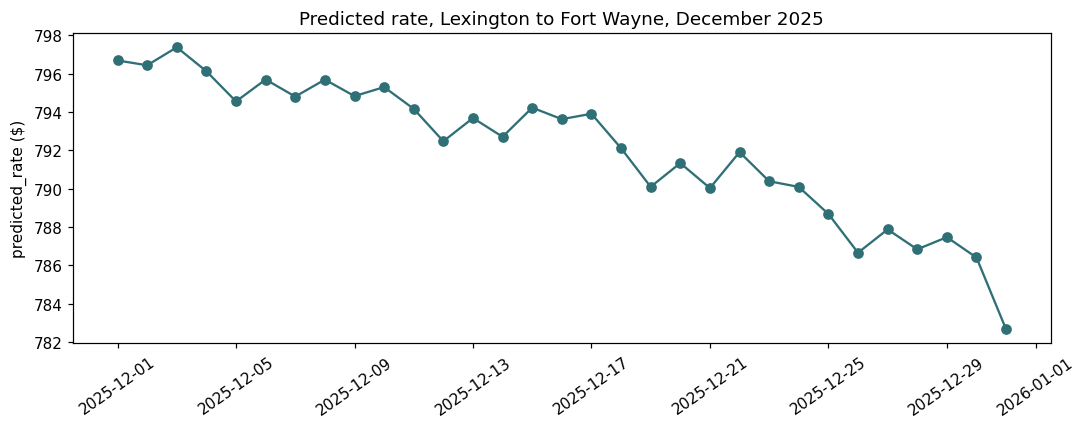

In [30]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(december_out["date"], december_out["predicted_rate"], marker="o", color="#2f6f76")
ax.set_title("Predicted rate, Lexington to Fort Wayne, December 2025")
ax.set_ylabel("predicted_rate ($)")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()


The curve is smooth day to day, which is the right behavior — the only thing changing across these
31 rows is the date, and the harmonic `market_index` extrapolation plus the cyclical day-of-year
features move gradually rather than jumping. No day-of-week effect shows up because none was found
in the training data (checked back in the EDA section).


## 11. Running the provided scorer

In [31]:
result = subprocess.run(
    ["python3", "score.py", "--predictions", "validation_predictions.csv", "--december-predictions", "december_predictions.csv"],
    capture_output=True, text=True,
)
print(result.stdout)
print(result.stderr)
result.returncode

Validated 12,000 final predictions.
Validated 31 fixed December predictions.
Created chart: scorer_results/candidate_december.png
Final validation metrics are calculated by Spotter after submission.




0

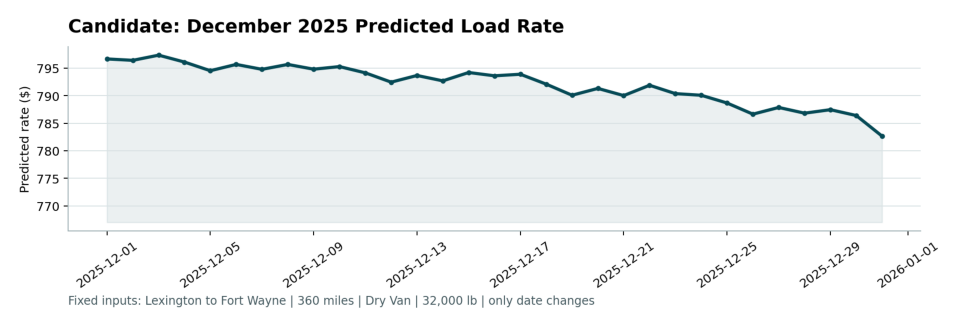

In [32]:
from matplotlib.image import imread
chart = imread("scorer_results/candidate_december.png")
plt.figure(figsize=(11, 5))
plt.imshow(chart)
plt.axis("off")
plt.show()